# 集成学习：Bagging 与随机森林

**课程 0009 配套练习** · 内核：`deeplearning`

前置：课程 0007（决策树）+ 0005（偏差-方差）。单棵决策树高方差：数据抖一抖树就换一棵。本课把很多棵「又笨又抖」的树放一起投票，让方差互相抵消——这就是 **Bagging**，加一层特征随机就是**随机森林**。

> 读完后请回答：为什么集成能降方差而不升偏差？

## 问题设定：咬合的月牙（noise 高）

noise=0.3 的月牙数据上，单棵深树 train≈1.0 但 test 差——典型高方差。看集成能不能救。

train: (350, 2) test: (150, 2)


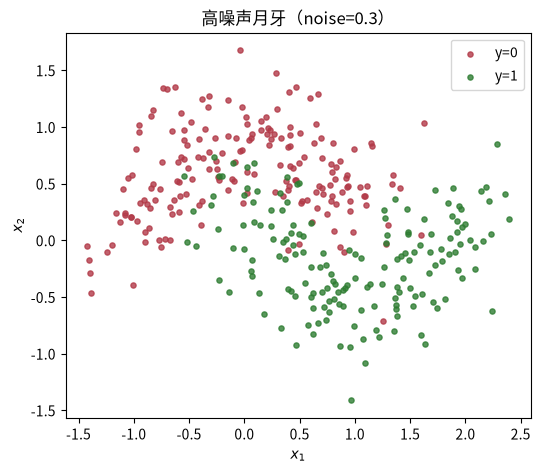

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=500, noise=0.3, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
print("train:", Xtr.shape, "test:", Xte.shape)

plt.figure(figsize=(6, 5))
plt.scatter(Xtr[ytr == 0, 0], Xtr[ytr == 0, 1], c="#b23a48", s=14, alpha=0.8, label="y=0")
plt.scatter(Xtr[ytr == 1, 0], Xtr[ytr == 1, 1], c="#2e7d32", s=14, alpha=0.8, label="y=1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.title("高噪声月牙（noise=0.3）")
plt.show()

## Bootstrap：自助采样

有放回地抽 N 次。每个样本被抽到的概率 $1 - (1-1/N)^N \to 1 - 1/e \approx 63.2\%$，所以约 **36.8% 抽不到**——这些是袋外（OOB）样本。

先写一个 bootstrap 采样函数验证这个比例。

In [2]:
def bootstrap_indices(rng, n):
    """有放回地抽 n 个索引。返回 (被抽中集合, 袋外索引)。"""
    idx = rng.integers(0, n, size=n)
    in_bag = np.unique(idx)
    oob = np.setdiff1d(np.arange(n), in_bag)        # Find the set difference of two arrays.
    return idx, oob

rng = np.random.default_rng(0)
_, oob = bootstrap_indices(rng, 10000)
print("袋外比例：", round(len(oob) / 10000, 4), "（理论约 0.368）")

袋外比例： 0.365 （理论约 0.368）


## 从零实现 Bagging

流程：bootstrap 抽子集 → 每棵深树长满 → 预测时多数投票。先复用 0007 的手写决策树（无剪枝深树）。

In [ ]:
from sklearn.tree import DecisionTreeClassifier

def fit_bagging(X, y, n_trees=50, max_features=None, seed=0):
    """返回 (树列表, 每棵树的 OOB 索引列表)。max_features=None 则用全部特征（纯 Bagging）。"""
    rng = np.random.default_rng(seed)       # 同一个 rng 对象，连续多次调用函数 → 结果每次不一样（rng 内部状态会向前推进，消耗随机数）
    n = len(X)
    trees, oobs = [], []
    for t in range(n_trees):        # Bagging 不会因为树太多而过拟合！增加树不会损害测试集，只是收益饱和。(就是会增加计算量)
        idx, oob = bootstrap_indices(rng, n)
        tree = DecisionTreeClassifier(random_state=t)  # 深树，不剪枝   # 设置随机种子t。决策树在选特征、划分样本时存在随机行为，固定该参数，保证每次运行生成的树完全一致，结果可复现。
        tree.fit(X[idx], y[idx])
        trees.append(tree)
        oobs.append(oob)
    return trees, oobs

def predict_bagging(trees, X):
    """多数投票。"""
    # print(trees[0].predict(X).shape)  # (n_test,)
    # print(trees[0].predict(X))        # [0 1 1 ... 0 1 0]，行向量
    votes = np.vstack([tree.predict(X) for tree in trees])  # (n_trees, n_test) # 就是n棵树对测试集的预测结果
    return np.array([np.bincount(v.astype(int)).argmax() for v in votes.T])

trees, oobs = fit_bagging(Xtr, ytr, n_trees=50)
print("单棵树 test 平均：", round(float(np.mean([t.score(Xte, yte) for t in trees])), 3))
print("Bagging 投票 test：", round(float(np.mean(predict_bagging(trees, Xte) == yte)), 3))

单棵树 test 平均： 0.858
(150,)
[0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 1 0 1 1 0 1 0
 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 0 1 1
 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 1
 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0 1 0 0
 1 1]
Bagging 投票 test： 0.893


## 随机森林：再加一层「特征随机」

所有树都用全部特征时，最强特征被每棵树第一个用 → 树高度相关，抵消不了方差。随机森林分裂时只从 **√p** 个随机特征里选（sklearn 的 `max_features='sqrt'`），树之间更独立。

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 随机森林两个随机:抽样 + 特征随机采样，降低树之间相关性，抑制过拟合。
single = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xtr, ytr)     # 分类任务默认sqrt为最大特征树，每次树分裂，只随机选 **√特征总数 ** 个候选特征做划分。
rf_full = RandomForestClassifier(n_estimators=200, max_features=None, random_state=0).fit(Xtr, ytr)

print("单棵深树  train/test：", round(single.score(Xtr, ytr), 3), round(single.score(Xte, yte), 3))
print("Bagging(全特征) train/test：", round(rf_full.score(Xtr, ytr), 3), round(rf_full.score(Xte, yte), 3))
print("随机森林   train/test：", round(rf.score(Xtr, ytr), 3), round(rf.score(Xte, yte), 3))

单棵深树  train/test： 1.0 0.86
Bagging(全特征) train/test： 1.0 0.873
随机森林   train/test： 1.0 0.887


## OOB 分数：不切验证集也能估误差

sklearn 的 `oob_score` 用每棵树的袋外样本估它的误差再平均——结果和交叉验证非常接近，省去切验证集的麻烦。

In [5]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=0).fit(Xtr, ytr)
print("OOB 分数：", round(rf_oob.oob_score_, 3))
print("test 准确率：", round(rf_oob.score(Xte, yte), 3))
print("（两者接近 → OOB 是免费且可信的验证）")

OOB 分数： 0.891
test 准确率： 0.887
（两者接近 → OOB 是免费且可信的验证）


## 特征重要性（真实数据）

乳腺癌数据集（30 个特征）上，随机森林给每个特征打分——比单棵树的统计稳得多，是特征筛选的常用起点。

In [ ]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.3, random_state=0)

rf_b = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xb_tr, yb_tr)
# Bagging 不会因为树太多而过拟合！增加树不会损害测试集，只是收益饱和。
print("乳腺癌 单树 test：", round(DecisionTreeClassifier(random_state=0).fit(Xb_tr, yb_tr).score(Xb_te, yb_te), 3))
print("乳腺癌 RF   test：", round(rf_b.score(Xb_te, yb_te), 3))

imp = rf_b.feature_importances_
top = np.argsort(imp)[::-1][:5]
print("\nTop-5 特征：")
for i in top:
    print(f"  {bc.feature_names[i]:<28} {imp[i]:.3f}")

乳腺癌 单树 test： 0.912
乳腺癌 RF   test： 0.959

Top-5 特征：
  mean concave points          0.139
  worst concave points         0.137
  worst perimeter              0.114
  worst radius                 0.093
  worst area                   0.088


## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 用 `bootstrap_indices` 做多次实验：`n=50, 200, 2000`，各跑 100 次统计袋外比例的平均值，验证它收敛到 36.8%。

**S2.** 单棵深树 train=1.0 而随机森林 train≈0.99，为什么随机森林「故意」不背训练集却更好？结合「降方差」解释。

**M1.** 把 `n_estimators` 从 1 扫到 200，画 Bagging test 准确率随树数变化的曲线，看它什么时候「收敛」，之后再加树还有没有用。

**M2.** 对比三者的 test 准确率：单树 / Bagging 全特征 / 随机森林（√p 特征），用数字说明「特征子采样」到底贡献了多少提升。

**H1.** 在月牙数据上画出单棵深树 vs 随机森林的决策边界并排对比，观察随机森林边界为什么更平滑。

**H2.** 面试题：为什么说「随机森林对高方差模型有效、对低方差模型帮助有限」？如果你把线性回归做 Bagging，测试准确率会明显提升吗？（可以实际试一下：`RandomForestRegressor` 或对逻辑回归做 Bagging。）

In [ ]:
# pass  # 练习区（S1/S2）
# 单棵树可以完全拟合训练集，但树之间预测不完全对齐，集成后不会完全复刻训练集输出，训练集略降，但测试集变好。

In [ ]:
# pass  # 练习区（M1/M2）
# Bagging 不会因为树太多而过拟合！增加树不会损害测试集，只是收益饱和。

In [ ]:
# pass  # 练习区（H1/H2）
# 把线性回归做 Bagging，测试准确率不会明显提升。
# 线性回归本身是低方差高偏差模型，Bagging 不改善偏差；基模型之间相关性很高，没法有效降方差。